# **Facial Emotion Detection**

## **Problem Definition**

**The context:** Why is this problem important to solve?<br>
**The objectives:** What is the intended goal?<br>
**The key questions:** What are the key questions that need to be answered?<br>
**The problem formulation:** What are we trying to solve using data science?



## **About the dataset**

The data set consists of 3 folders, i.e., 'test', 'train', and 'validation'.
Each of these folders has four subfolders:

**‘happy’**: Images of people who have happy facial expressions.<br>
**‘sad’**: Images of people with sad or upset facial expressions.<br>
**‘surprise’**: Images of people who have shocked or surprised facial expressions.<br>
**‘neutral’**: Images of people showing no prominent emotion in their facial expression at all.<br>


## **Mounting the Drive**

**NOTE:**  Please use Google Colab from your browser for this notebook. **Google.colab is NOT a library that can be downloaded locally on your device.**

In [ ]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Importing the Libraries**

In [ ]:
# Basic libraries
import numpy as np
import pandas as pd
import tensorflow as tf
import random

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator

# Deep learning libraries
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Activation, LeakyReLU, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Import Keras backend
from tensorflow.keras import backend

from sklearn.metrics import confusion_matrix, classification_report

# File handling libraries
import zipfile
import os

### **Let us load and unzip the data**

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same on your Google drive before executing the code in the next cell.
- In case of any error, please make sure that the path of the file is correct as the path may be different for you.

In [ ]:
# Path of dataset zip file
path = '/content/drive/MyDrive/Facial_emotion_images.zip'

# Extracting files
with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
# Define the size of the images and the path to where the data was unzipped
image_size = 48
folder_path = '/content/Facial_emotion_images'

## **Visualizing our Classes**

Let's look at our classes.

**Write down your observation for each class. What do you think can be a unique feature of each emotion, that separates it from the remaining classes?**

### **Happy**

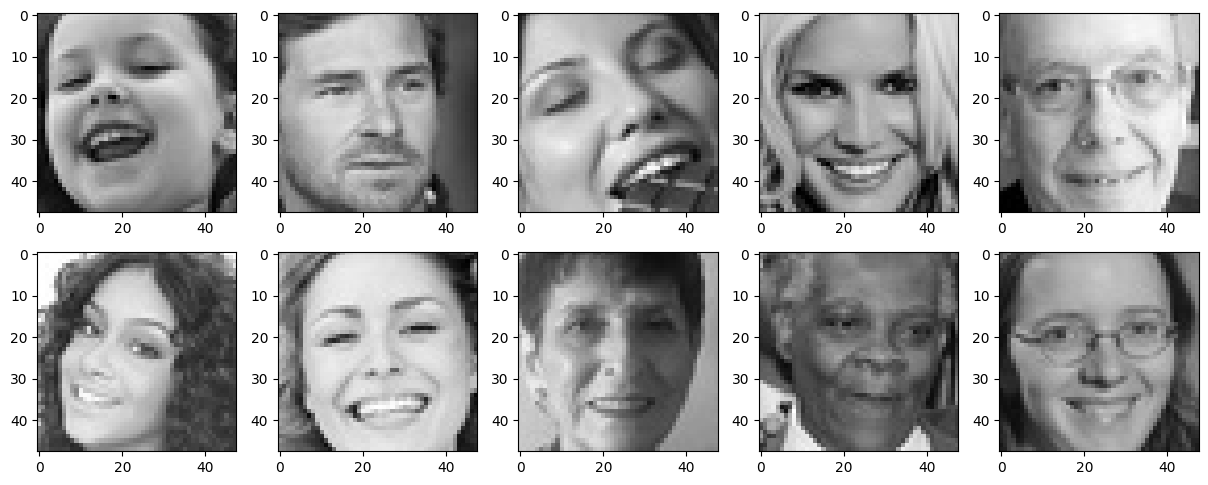

In [ ]:
plt.figure(figsize=(15, 15))

for i in range(1, 11):
    plt.subplot(5, 5, i)

    img = load_img(folder_path + '/train/happy/' + os.listdir('/content/Facial_emotion_images/train/happy/')[i], target_size=(image_size, image_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:** While a smile is generally a good indicator of happiness, not all pictures labelled happy have the person smiling, or some smiles may not be as obvious. Other features that can indicate happiness are cheeks raised, wrinkles around eyes and more prominent nasolabial folds. While there is a picture of someone eating chocolate, this may not be common in the entire set, and is also likely to be included in pictures of people who are sad as well.

### **Sad**

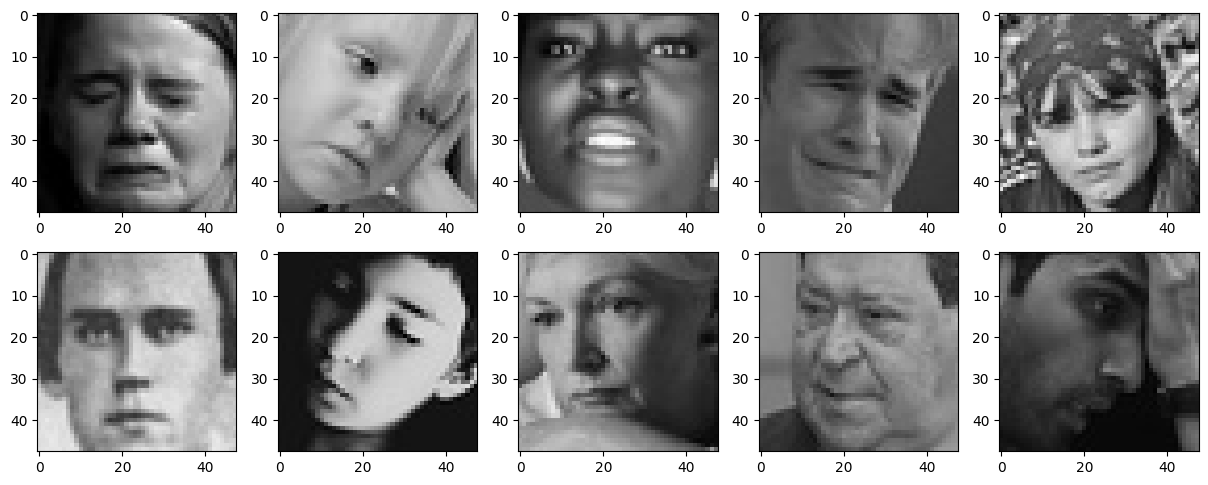

In [ ]:
plt.figure(figsize=(15, 15))

for i in range(1, 11):
    plt.subplot(5, 5, i)

    img = load_img(folder_path + '/train/sad/' + os.listdir('/content/Facial_emotion_images/train/sad/')[i], target_size=(image_size, image_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:** For sad, people are generally frowning or crying/have scrunched up eyes and furrowed brows. In some photos people have one hand somewhere in the picture, either on their forehead or side of their face. While not always the case, in general it seems that peoples teeth aren't usually visible in pictures where they are sad.

### **Neutral**

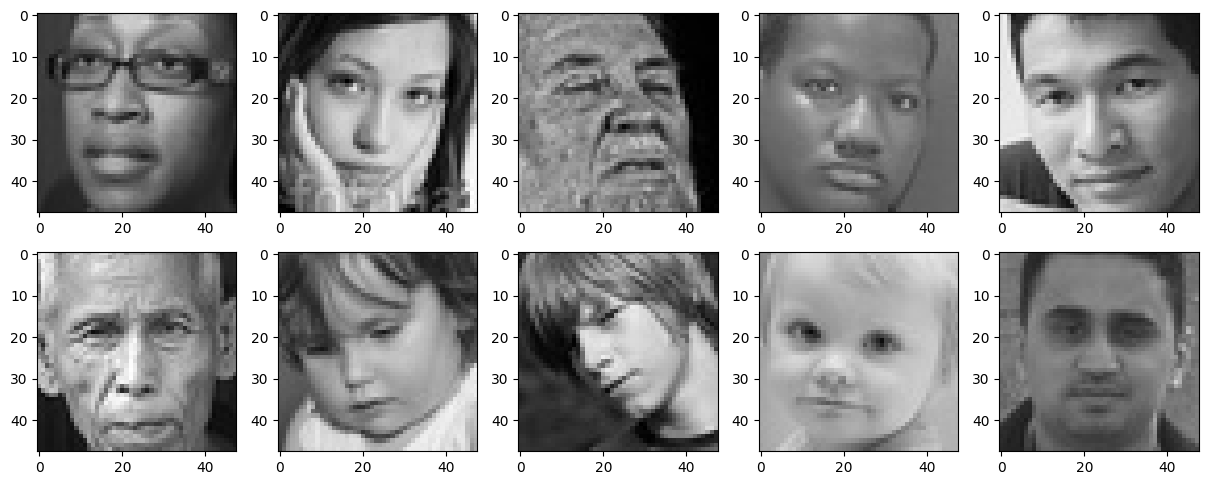

In [ ]:
plt.figure(figsize=(15, 15))

for i in range(11, 21):
    plt.subplot(5, 5, i)

    img = load_img(folder_path + '/train/neutral/' + os.listdir('/content/Facial_emotion_images/train/neutral/')[i], target_size=(image_size, image_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:** For neutral, in general peoples facial features are all relaxed, so not smiling or frowning and not raising eyebrows or furrowing eyebrows. They don't generally show their teeth and their hands don't appear to be in the picture much compared to sad/surprised.

### **Surprised**

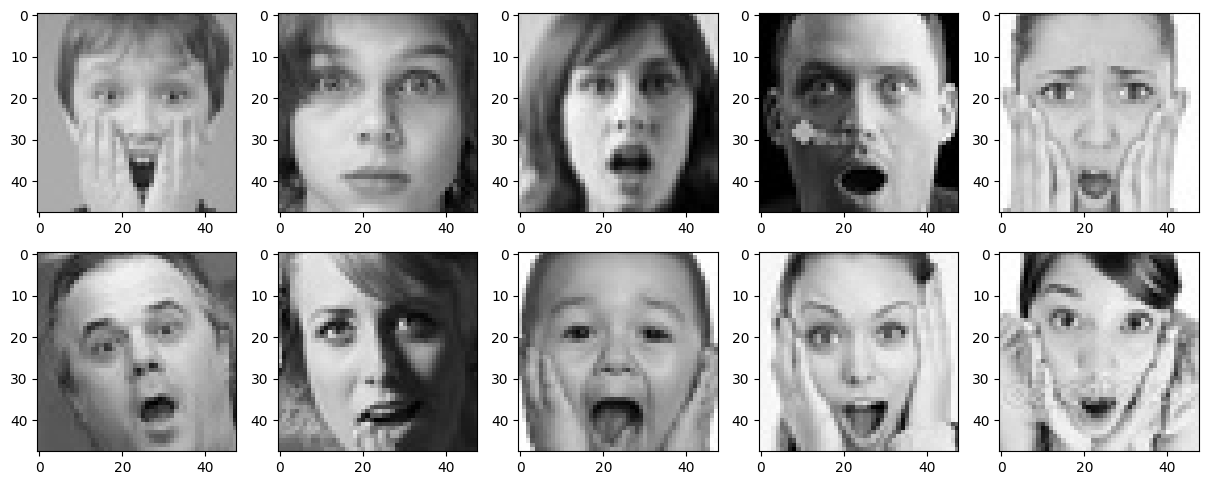

In [ ]:
plt.figure(figsize=(15, 15))

for i in range(1, 11):
    plt.subplot(5, 5, i)

    img = load_img(folder_path + '/train/surprise/' + os.listdir('/content/Facial_emotion_images/train/surprise/')[i], target_size=(image_size, image_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:** The most obvious signs for suprised are a wide open mouth, big eyes, raised eyebrows and sometimes with their hands on both sides of their face.

## **Checking Distribution of Classes**

Number of images in class happy: 3976
Number of images in class sad: 3982
Number of images in class neutral: 3978
Number of images in class surprised: 3173


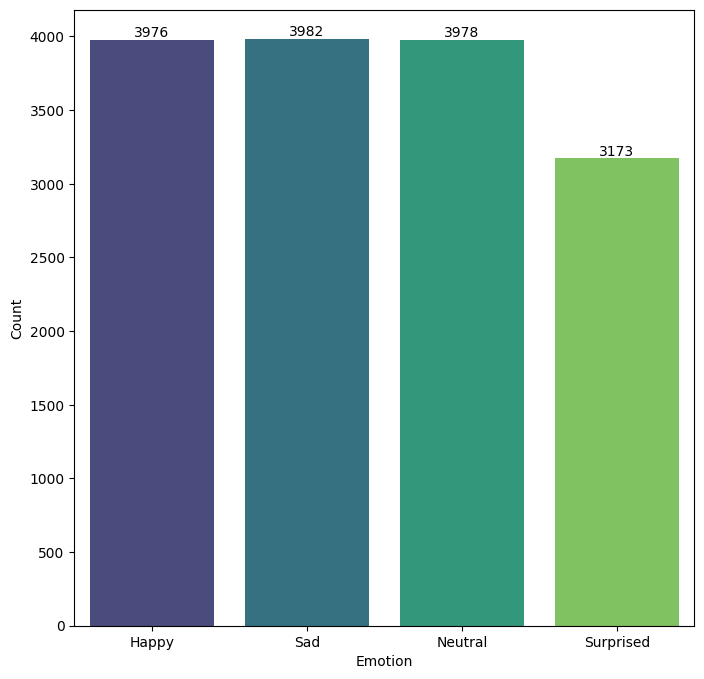

In [ ]:
# Count how many images of each type are in the training set.
num_happy = len(os.listdir(folder_path + '/train/happy'))
print('Number of images in class happy:', num_happy)

num_sad = len(os.listdir(folder_path + '/train/sad'))
print('Number of images in class sad:', num_sad)

num_neutral = len(os.listdir(folder_path + '/train/neutral'))
print('Number of images in class neutral:', num_neutral)

num_surprised = len(os.listdir(folder_path + '/train/surprise'))
print('Number of images in class surprised:', num_surprised)

# Create DataFrame of the data
data = {'Emotion': ['Happy', 'Sad', 'Neutral', 'Surprised'],
        'Count': [num_happy, num_sad, num_neutral, num_surprised]}

df = pd.DataFrame(data)

# Plot a bar graph of the number of images in each class
plt.figure(figsize=(8, 8))

sns.barplot(x='Emotion', y='Count', data=df, palette='viridis')

for index, value in enumerate(df['Count']):
    plt.text(index, value + 0.1, str(value), ha='center', va='bottom')

plt.show()

**Observations and Insights:** The amount of images in happy, sad and neutral are almost the same, but there are about 3/4 of images for the surprised class. This could potentially lead to poor generalization in the model. If this turns out to be the case, we can augment the data to balance the classes out.

**Think About It:**
* Are the classes equally distributed? If not, do you think the imbalance is too high? Will it be a problem as we progress?
* Are there any Exploratory Data Analysis tasks that we can do here? Would they provide any meaningful insights?

## **Creating our Data Loaders**

In this section, we are creating data loaders that we will use as inputs to our Neural Network.

**You have two options for the color_mode. You can set it to color_mode = 'rgb' or color_mode = 'grayscale'. You will need to try out both and see for yourself which one gives better performance.**

In [ ]:
batch_size  = 32

# Creating data generators for train, validation and test set with color_mode = 'rgb'
datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

train_set = datagen_train.flow_from_directory('Facial_emotion_images/train',
                                              target_size = (image_size, image_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)

datagen_validation = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

validation_set = datagen_validation.flow_from_directory('Facial_emotion_images/validation',
                                              target_size = (image_size, image_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)

datagen_test = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

test_set = datagen_test.flow_from_directory('Facial_emotion_images/test',
                                              target_size = (image_size, image_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


In [ ]:
# Creating data generators for train, validation and test set with color_mode = 'grayscale'
datagen_train_gray = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

train_set_gray = datagen_train_gray.flow_from_directory('Facial_emotion_images/train',
                                              target_size = (image_size, image_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)

datagen_validation_gray = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

validation_set_gray = datagen_validation_gray.flow_from_directory('Facial_emotion_images/validation',
                                              target_size = (image_size, image_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)

datagen_test_gray = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

test_set_gray = datagen_test_gray.flow_from_directory('Facial_emotion_images/test',
                                              target_size = (image_size, image_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


## **Model Building**

**Think About It:**
* Are Convolutional Neural Networks the right approach? Should we have gone with Artificial Neural Networks instead?
* What are the advantages of CNNs over ANNs and are they applicable here?

### **Creating the Base Neural Network**

In [ ]:
# Fixing the seed
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Input shape with of image_size x image_size, and 3 channels for rgb
input_shape=(image_size, image_size, 3)
num_classes=4

# Save the best model in model1.h5
checkpoint = ModelCheckpoint("./model1.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# Stop early if loss function doesn't improve
early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 3,
                          verbose = 1,
                          restore_best_weights = True
                          )

# Reduce learning rate if loss starts to plateau
reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 3,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

# Define the model
def cnn_model_1(input_shape=input_shape, num_classes=num_classes):
    # Initialize the model
    model = Sequential()

    # First Conv block
    model.add(Conv2D(64, (2, 2), padding='same', activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))

    # Second Convolutional Block
    model.add(Conv2D(32, (2, 2), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))

    # Third Convolutional Block
    model.add(Conv2D(32, (2, 2), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))

    # Flatten layer
    model.add(Flatten())

    # Dense layers
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(4, activation='softmax'))

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model


In [ ]:
model1 = cnn_model_1()

model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 64)        832       
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 24, 24, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 32)        8224      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 12, 12, 32)        0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 12, 12, 32)        0

In [ ]:
history = model1.fit(train_set,
                    epochs=20,
                    validation_data=validation_set,
                    callbacks=callbacks_list)

Epoch 1/20
473/473 [==============================] - ETA: 0s - loss: 1.3313 - accuracy: 0.3363
Epoch 1: val_accuracy improved from -inf to 0.46253, saving model to ./model1.h5
473/473 [==============================] - 123s 255ms/step - loss: 1.3313 - accuracy: 0.3363 - val_loss: 1.2203 - val_accuracy: 0.4625 - lr: 0.0010


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 2/20
473/473 [==============================] - ETA: 0s - loss: 1.1912 - accuracy: 0.4642
Epoch 2: val_accuracy improved from 0.46253 to 0.52080, saving model to ./model1.h5
473/473 [==============================] - 98s 208ms/step - loss: 1.1912 - accuracy: 0.4642 - val_loss: 1.1039 - val_accuracy: 0.5208 - lr: 0.0010
Epoch 3/20
473/473 [==============================] - ETA: 0s - loss: 1.1143 - accuracy: 0.5115
Epoch 3: val_accuracy improved from 0.52080 to 0.56018, saving model to ./model1.h5
473/473 [==============================] - 89s 187ms/step - loss: 1.1143 - accuracy: 0.5115 - val_loss: 1.0304 - val_accuracy: 0.5602 - lr: 0.0010
Epoch 4/20
473/473 [==============================] - ETA: 0s - loss: 1.0730 - accuracy: 0.5227
Epoch 4: val_accuracy improved from 0.56018 to 0.57565, saving model to ./model1.h5
473/473 [==============================] - 88s 186ms/step - loss: 1.0730 - accuracy: 0.5227 - val_loss: 0.9898 - val_accuracy: 0.5756 - lr: 0.0010
Epoch 5/20
473/473 

In [ ]:
# Clear backend
backend.clear_session()

# Fixing the seed after clearing backend
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Change number of channels to 1 for grayscale
input_shape=(image_size, image_size, 1)
model1_gray = cnn_model_1(input_shape)

model1_gray.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 64)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 24, 24, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 32)        8224      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 12, 12, 32)        0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 12, 12, 32)        0

In [ ]:
# Save best model as ./model2.h5
checkpoint = ModelCheckpoint("./model2.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

history1 = model1_gray.fit(train_set_gray,
                    epochs=20,
                    validation_data=validation_set_gray,
                    callbacks=callbacks_list)

Epoch 1/20
473/473 [==============================] - ETA: 0s - loss: 1.3243 - accuracy: 0.3366
Epoch 1: val_accuracy improved from -inf to 0.44384, saving model to ./model2.h5
473/473 [==============================] - 78s 162ms/step - loss: 1.3243 - accuracy: 0.3366 - val_loss: 1.2530 - val_accuracy: 0.4438 - lr: 0.0010
Epoch 2/20
473/473 [==============================] - ETA: 0s - loss: 1.1991 - accuracy: 0.4526
Epoch 2: val_accuracy improved from 0.44384 to 0.52923, saving model to ./model2.h5
473/473 [==============================] - 76s 162ms/step - loss: 1.1991 - accuracy: 0.4526 - val_loss: 1.1075 - val_accuracy: 0.5292 - lr: 0.0010
Epoch 3/20
473/473 [==============================] - ETA: 0s - loss: 1.1240 - accuracy: 0.4994
Epoch 3: val_accuracy improved from 0.52923 to 0.54029, saving model to ./model2.h5
473/473 [==============================] - 76s 161ms/step - loss: 1.1240 - accuracy: 0.4994 - val_loss: 1.0574 - val_accuracy: 0.5403 - lr: 0.0010
Epoch 4/20
473/473 [==

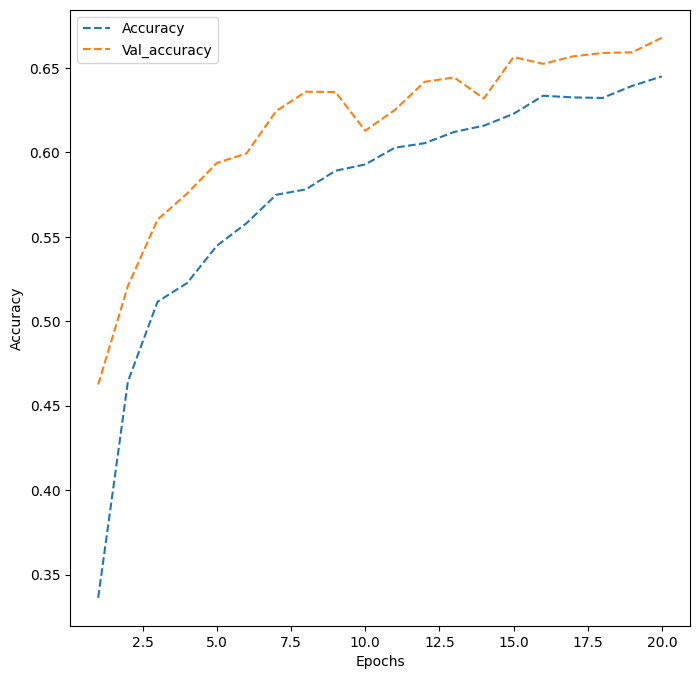

In [ ]:
# Plotting training and validation accuracies
dict_hist = history.history
list_epochs = [i for i in range(1, 21)]

plt.figure(figsize=(8, 8))

plt.plot(list_epochs, dict_hist['accuracy'], ls='--', label='Accuracy')
plt.plot(list_epochs, dict_hist['val_accuracy'], ls='--', label='Val_accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

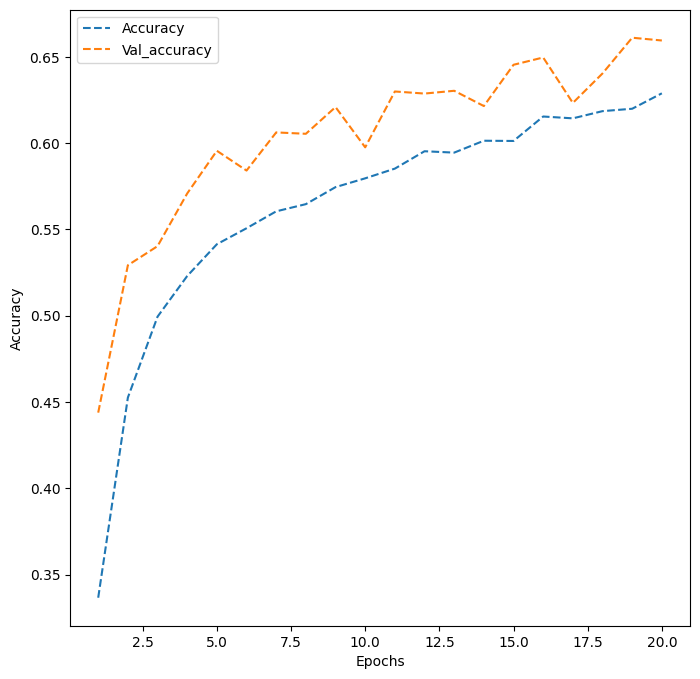

In [ ]:
# Plot training and validation accuracies
dict_hist1 = history1.history

plt.figure(figsize=(8, 8))

plt.plot(list_epochs, dict_hist1['accuracy'], ls='--', label='Accuracy')
plt.plot(list_epochs, dict_hist1['val_accuracy'], ls='--', label='Val_accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

**Observations:** The accuracy values are roughly the same using both 'rgb' and 'grayscale'. The validation and training accuracy aren't too different from each other, suggesting that neither model is overfitting.

### **Evaluating the Model on the Test Set**

In [ ]:
# Get next set of images and labels from test set
test_images, test_labels = next(test_set)

In [ ]:
accuracy1 = model1.evaluate(test_images, test_labels, verbose=2)

1/1 - 0s - loss: 0.8332 - accuracy: 0.7188 - 40ms/epoch - 40ms/step


1/1 [==============================] - 0s 43ms/step
              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.75      0.90      0.82        10
           2       0.67      0.67      0.67         9
           3       0.71      0.62      0.67         8

    accuracy                           0.72        32
   macro avg       0.72      0.70      0.70        32
weighted avg       0.72      0.72      0.71        32



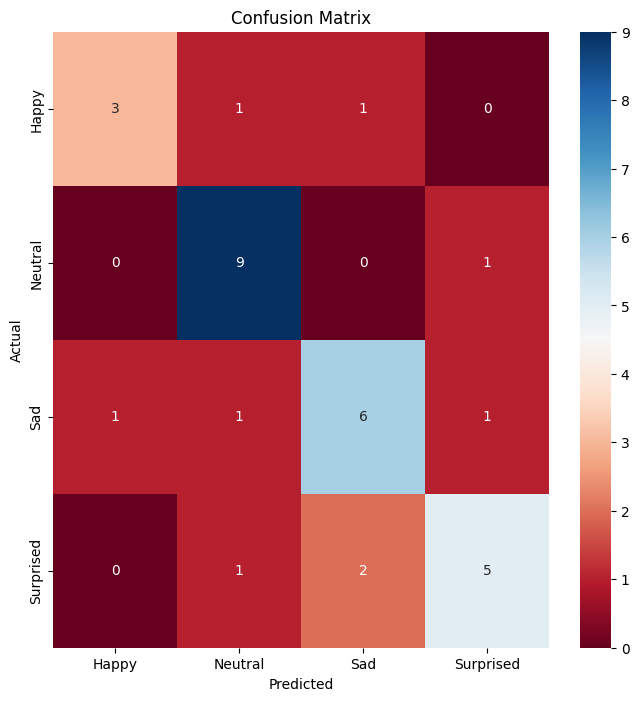

In [ ]:
pred = model1.predict(test_images)

# Turn predicted values into single values
pred = np.argmax(pred, axis=1)
y_true = np.argmax(test_labels, axis=1)

# Print classification report
print(classification_report(y_true, pred))

cm = confusion_matrix(y_true, pred)

# Get class labels
classes = ['Happy', 'Neutral', 'Sad', 'Surprised']

# Plot the heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='.0f', xticklabels=classes, yticklabels=classes, cmap='RdBu')

# Set labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Show the plot
plt.show()

**Observations and Insights:** The accuracy on the test data is 72%. The f1 scores for happy, sad and surprised are all 0.67, whereas it's 0.82 for neutral, which is also the most common class in the test set. This, paired with a small amount of data in the test set is the most likely cause of the test data outperforming the training data.

### **Creating the second Convolutional Neural Network**

- Try out a slightly larger architecture

In [ ]:
# Clear backend
backend.clear_session()

# Fixing the seed after clearing backend
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Set input_shape with 3 channels for rgb and set up callbacks.
input_shape = (input_shape, input_shape, 3)

checkpoint = ModelCheckpoint("./model3.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 3,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 3,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]


def cnn_model_2(input_shape=input_shape, num_classes=num_classes):
    # Initialize the CNN
    model = Sequential()

    # First Convolutional Block
    model.add(Conv2D(128, (2, 2), padding='same', activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.1))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Second Convolutional Block
    model.add(Conv2D(64, (2, 2), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.1))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Third Convolutional Block
    model.add(Conv2D(64, (2, 2), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.1))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Fourth Convolutional Block
    model.add(Conv2D(32, (2, 2), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.1))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Flatten layer
    model.add(Flatten())

    # Dense layers
    model.add(Dense(512, activation='relu'))
    model.add(Dense(4, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

### **Compiling and Training the Model**

In [ ]:
model3 = cnn_model_2()

model3.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 128)       1664      
                                                                 
 batch_normalization (Batch  (None, 48, 48, 128)       512       
 Normalization)                                                  
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 48, 48, 128)       0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 128)       0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        32832     
                                                                 
 batch_normalization_1 (Bat  (None, 24, 24, 64)        2

In [ ]:
history2 = model3.fit(train_set,
                     epochs=20,
                     validation_data=validation_set,
                     callbacks=callbacks_list)

Epoch 1/20
473/473 [==============================] - ETA: 0s - loss: 1.2896 - accuracy: 0.4046
Epoch 1: val_accuracy improved from -inf to 0.43239, saving model to ./model3.h5
473/473 [==============================] - 243s 508ms/step - loss: 1.2896 - accuracy: 0.4046 - val_loss: 1.2676 - val_accuracy: 0.4324 - lr: 0.0010
Epoch 2/20


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


473/473 [==============================] - ETA: 0s - loss: 1.0688 - accuracy: 0.5274
Epoch 2: val_accuracy improved from 0.43239 to 0.48302, saving model to ./model3.h5
473/473 [==============================] - 239s 505ms/step - loss: 1.0688 - accuracy: 0.5274 - val_loss: 1.1513 - val_accuracy: 0.4830 - lr: 0.0010
Epoch 3/20
473/473 [==============================] - ETA: 0s - loss: 0.9644 - accuracy: 0.5844
Epoch 3: val_accuracy improved from 0.48302 to 0.53084, saving model to ./model3.h5
473/473 [==============================] - 236s 498ms/step - loss: 0.9644 - accuracy: 0.5844 - val_loss: 1.0572 - val_accuracy: 0.5308 - lr: 0.0010
Epoch 4/20
473/473 [==============================] - ETA: 0s - loss: 0.9115 - accuracy: 0.6065
Epoch 4: val_accuracy improved from 0.53084 to 0.60719, saving model to ./model3.h5
473/473 [==============================] - 255s 539ms/step - loss: 0.9115 - accuracy: 0.6065 - val_loss: 0.9320 - val_accuracy: 0.6072 - lr: 0.0010
Epoch 5/20
473/473 [=======

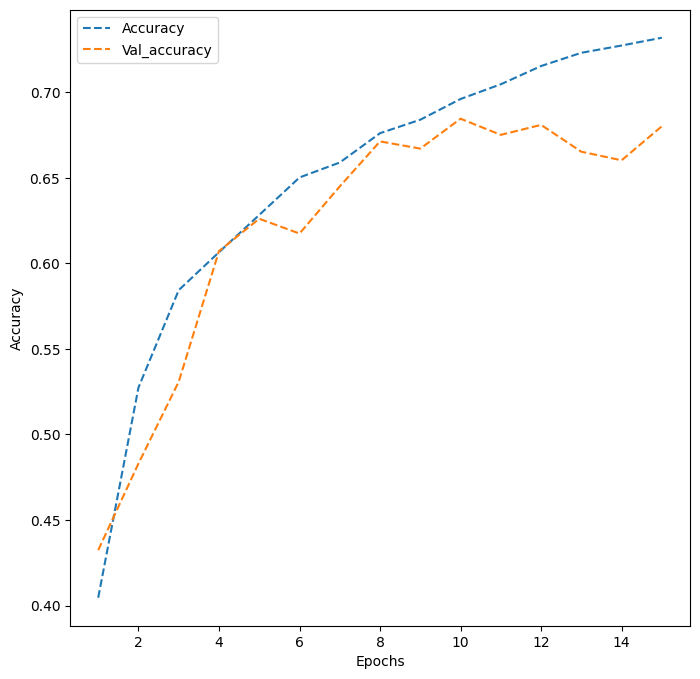

In [ ]:
# Plot training and validation accuracies
dict_hist2 = history2.history
list_epochs = [i for i in range(1, 16)]

plt.figure(figsize=(8, 8))

plt.plot(list_epochs, dict_hist2['accuracy'], ls='--', label='Accuracy')
plt.plot(list_epochs, dict_hist2['val_accuracy'], ls='--', label='Val_accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

**Observations:** The training accuracy is higher for this model, however the gap between training and validation accuracies is wider, hence the model is most likely overfitting. Adding Dropout layers to the network would be a good choice to reduce overfitting.

### **Evaluating the Model on the Test Set**

In [ ]:
# Print accuracy of second CNN
accuracy2 = model3.evaluate(test_images, test_labels, verbose=2)

1/1 - 0s - loss: 0.6765 - accuracy: 0.6875 - 188ms/epoch - 188ms/step


1/1 [==============================] - 1s 573ms/step
              precision    recall  f1-score   support

           0       0.60      0.60      0.60         5
           1       0.64      0.90      0.75        10
           2       0.71      0.56      0.63         9
           3       0.83      0.62      0.71         8

    accuracy                           0.69        32
   macro avg       0.70      0.67      0.67        32
weighted avg       0.70      0.69      0.68        32



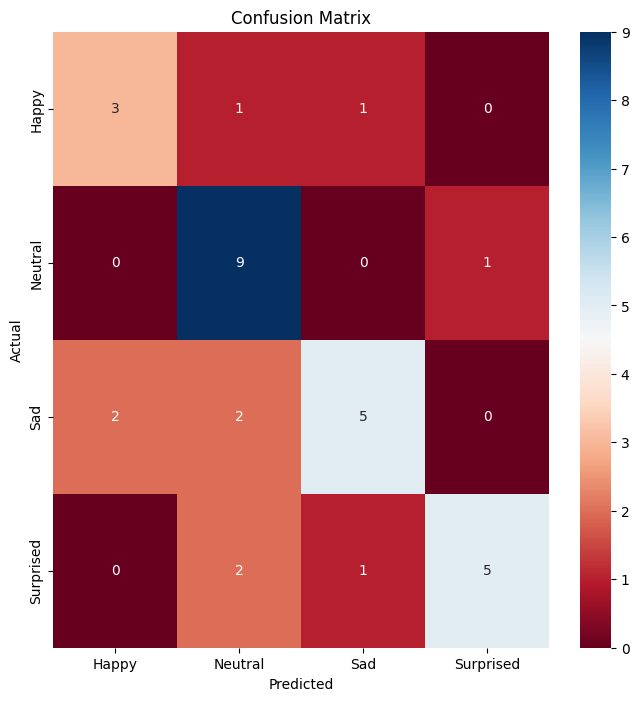

In [ ]:
pred = model3.predict(test_images)

# Turn predicted values into single values
pred = np.argmax(pred, axis=1)
y_true = np.argmax(test_labels, axis=1)

# Print classification report
print(classification_report(y_true, pred))

cm = confusion_matrix(y_true, pred)

# Get class labels
classes = ['Happy', 'Neutral', 'Sad', 'Surprised']

# Plot the heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='.0f', xticklabels=classes, yticklabels=classes, cmap='RdBu')

# Set labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Show the plot
plt.show()

**Observations and Insights:** Compared to the previous model on the same test set, the test accuracy is worse even though the training accuracy was higher, so that helps show that the model is most likely overfitting to the data. Once again the neutral class has the highest f1-score.

## **Think About It:**

* Did the models have a satisfactory performance? If not, then what are the possible reasons?
* Which Color mode showed better overall performance? What are the possible reasons? Do you think having 'rgb' color mode is needed because the images are already black and white?

## **Transfer Learning Architectures**

In this section, we will create several Transfer Learning architectures. For the pre-trained models, we will select three popular architectures namely, VGG16, ResNet v2, and Efficient Net. The difference between these architectures and the previous architectures is that these will require 3 input channels while the earlier ones worked on 'grayscale' images. Therefore, we need to create new DataLoaders.

### **Creating our Data Loaders for Transfer Learning Architectures**

In this section, we are creating data loaders that we will use as inputs to our Neural Network. We will have to go with color_mode = 'rgb' as this is the required format for the transfer learning architectures.

In [ ]:
batch_size  = 32

# Creating data generators for train, validation and test set with color_mode = 'rgb'
datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

train_set = datagen_train.flow_from_directory('Facial_emotion_images/train',
                                              target_size = (image_size, image_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)

datagen_validation = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

validation_set = datagen_validation.flow_from_directory('Facial_emotion_images/validation',
                                              target_size = (image_size, image_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)

datagen_test = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

test_set = datagen_test.flow_from_directory('Facial_emotion_images/test',
                                              target_size = (image_size, image_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


## **VGG16 Model**

### **Importing the VGG16 Architecture**

In [ ]:
# Clear backend
backend.clear_session()

# Fixing the seed after clearing backend
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import Model

# Import CNN part of VGG16 architecture and weights from imagenet
vgg = VGG16(include_top = False, weights = 'imagenet', input_shape = (48, 48, 3))
vgg.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 48, 48, 3)]       0         
                                                                 
 block1_conv1 (Conv2D)       (None, 48, 48, 64)        1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 48, 48, 64)        36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 24, 24, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 24, 24, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 24, 24, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 12, 12, 128)       0     

### **Model Building**

- Import VGG16 upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
# Copy up to the pooling layer of the third block
transfer_layer = vgg.get_layer('block3_pool')

# Set the weights to not be trained
vgg.trainable = False

# Flattenning the output from the 3rd block of the VGG16 model
x = Flatten()(transfer_layer.output)

# Adding a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)

# Adding a Dense Layer with 128 neurons
x = Dense(128, activation='relu')(x)

# Adding a Dropout layer with Dropout ratio of 0.3
x = Dropout(0.3)(x)

# Add a Dense Layer with 64 neurons
x = Dense(64, activation='relu')(x)

# Add a Batch Normalization layer
x = BatchNormalization()(x)

# Adding the final dense layer with 4 neurons and using 'softmax' activation
pred = Dense(4, activation='softmax')(x)

# Initializing the model
vggmodel = Model(vgg.input, pred)

### **Compiling and Training the VGG16 Model**

In [ ]:
checkpoint = ModelCheckpoint("./vggmodel.h5", monitor = 'val_loss', verbose = 1, save_best_only = True, mode = 'max')

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

In [ ]:
# Compile the model
vggmodel.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

vggmodel.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 48, 48, 3)]       0         
                                                                 
 block1_conv1 (Conv2D)       (None, 48, 48, 64)        1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 48, 48, 64)        36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 24, 24, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 24, 24, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 24, 24, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 12, 12, 128)       0   

In [ ]:
vggmodel.fit(train_set, epochs=20, batch_size=batch_size, validation_data=validation_set)

Epoch 1/20
473/473 [==============================] - 351s 738ms/step - loss: 1.1412 - accuracy: 0.4837 - val_loss: 0.9038 - val_accuracy: 0.6311
Epoch 2/20
473/473 [==============================] - 406s 859ms/step - loss: 0.9423 - accuracy: 0.5963 - val_loss: 0.9576 - val_accuracy: 0.5879
Epoch 3/20
473/473 [==============================] - 348s 736ms/step - loss: 0.9340 - accuracy: 0.6049 - val_loss: 0.8714 - val_accuracy: 0.6438
Epoch 4/20
473/473 [==============================] - 348s 737ms/step - loss: 0.9042 - accuracy: 0.6143 - val_loss: 0.8489 - val_accuracy: 0.6383
Epoch 5/20
473/473 [==============================] - 408s 863ms/step - loss: 0.8547 - accuracy: 0.6409 - val_loss: 0.8926 - val_accuracy: 0.6307
Epoch 6/20
473/473 [==============================] - 348s 735ms/step - loss: 0.8375 - accuracy: 0.6472 - val_loss: 0.8089 - val_accuracy: 0.6687
Epoch 7/20
473/473 [==============================] - 347s 732ms/step - loss: 0.8164 - accuracy: 0.6611 - val_loss: 0.7917 -

### **Evaluating the VGG16 model**

In [ ]:
accuracy_vgg = vggmodel.evaluate(test_images, test_labels, verbose=2)

1/1 - 2s - loss: 0.7762 - accuracy: 0.6875 - 2s/epoch - 2s/step


1/1 [==============================] - 1s 782ms/step
              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.56      1.00      0.71        10
           2       0.83      0.56      0.67         9
           3       1.00      0.50      0.67         8

    accuracy                           0.69        32
   macro avg       0.78      0.66      0.68        32
weighted avg       0.78      0.69      0.68        32



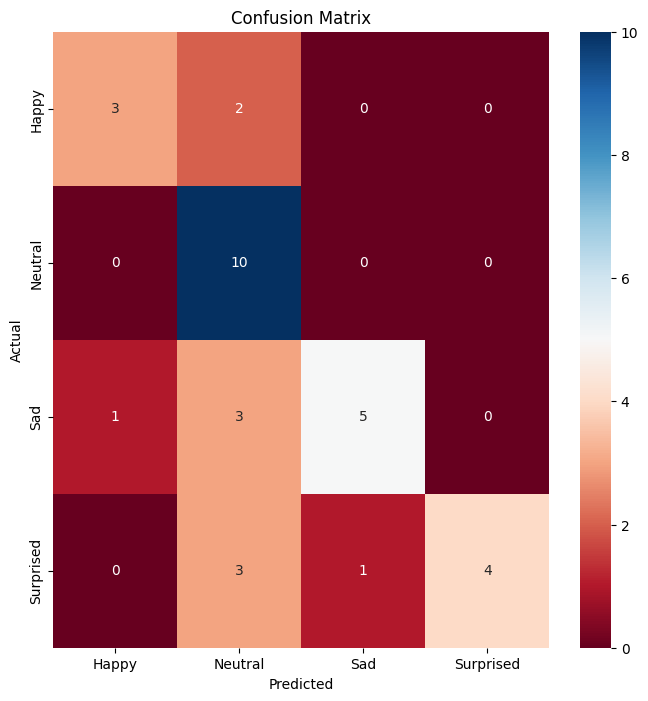

In [ ]:
pred = vggmodel.predict(test_images)

# Turn predicted values into single values
pred = np.argmax(pred, axis=1)
y_true = np.argmax(test_labels, axis=1)

# Print classification report
print(classification_report(y_true, pred))

cm = confusion_matrix(y_true, pred)

# Get class labels
classes = ['Happy', 'Neutral', 'Sad', 'Surprised']

# Plot the heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='.0f', xticklabels=classes, yticklabels=classes, cmap='RdBu')

# Set labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Show the plot
plt.show()

**Think About It:**

- What do you infer from the general trend in the training performance?
- Is the training accuracy consistently improving?
- Is the validation accuracy also improving similarly?

**Observations and Insights:** The training accuracy was constantly improving,but the validation accuracy stopped increasing. As the training, validation and test accuracy were all pretty similar, transferring up to before the pooling layer of the 4th convolution block and perhaps adding a 5th convolution layer to increase the complexity might help the model better capture the underlying patterns in the data and improve the score.

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance**

## **ResNet V2 Model**

In [ ]:
# Clear backend
backend.clear_session()

# Fixing the seed after clearing backend
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### **Model Building**

- Import Resnet v2 upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
import tensorflow.keras.applications as ap

# Transferring CNN architecture of ResNet
Resnet = ap.ResNet101(include_top = False, weights = "imagenet", input_shape=(48,48,3))
Resnet.summary()

171446536/171446536 [==============================] - 1s 0us/step
Model: "resnet101"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 48, 48, 3)]          0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 54, 54, 3)            0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 24, 24, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 24, 24, 64)           256       ['conv1_conv[0][0]']          
 on)                   

### **Compiling and Training the Model**

In [ ]:
transfer_layer_Resnet = Resnet.get_layer('conv5_block3_add')
Resnet.trainable=False

# Flattenning the output from the 3rd block of the VGG16 model
x = Flatten()(transfer_layer_Resnet.output)

# Add a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)

# Add a Dense Layer with 128 neurons
x = Dense(128, activation='relu')(x)

# Add a DropOut layer with Drop out ratio of 0.3
x = Dropout(0.3)(x)

# Add a Dense Layer with 64 neurons
x = Dense(64, activation='relu')(x)

# Add a Batch Normalization layer
x = BatchNormalization()(x)

# Add the final dense layer with 4 neurons and use a 'softmax' activation
pred = Dense(4, activation='softmax')(x)

# Initializing the model
resnetmodel = Model(Resnet.input, pred)

In [ ]:
checkpoint = ModelCheckpoint("./resmodel.h5", monitor = 'val_loss', verbose = 1, save_best_only = True, mode = 'max')

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

In [ ]:
# Compile the model
resnetmodel.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

resnetmodel.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 48, 48, 3)]          0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 54, 54, 3)            0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 24, 24, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 24, 24, 64)           256       ['conv1_conv[0][0]']          
 on)                                                                                          

In [ ]:
history_res = resnetmodel.fit(train_set,
                              epochs=20,
                              batch_size=batch_size,
                              validation_data=validation_set,
                              callbacks=callbacks_list)

Epoch 1/20
473/473 [==============================] - ETA: 0s - loss: 1.4683 - accuracy: 0.2683
Epoch 1: val_loss improved from -inf to 1.41518, saving model to ./resmodel.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


473/473 [==============================] - 384s 790ms/step - loss: 1.4683 - accuracy: 0.2683 - val_loss: 1.4152 - val_accuracy: 0.2443 - lr: 0.0010
Epoch 2/20
473/473 [==============================] - ETA: 0s - loss: 1.4014 - accuracy: 0.2617
Epoch 2: val_loss did not improve from 1.41518
473/473 [==============================] - 365s 773ms/step - loss: 1.4014 - accuracy: 0.2617 - val_loss: 1.3660 - val_accuracy: 0.3667 - lr: 0.0010
Epoch 3/20
473/473 [==============================] - ETA: 0s - loss: 1.3988 - accuracy: 0.2677
Epoch 3: val_loss did not improve from 1.41518
473/473 [==============================] - 419s 887ms/step - loss: 1.3988 - accuracy: 0.2677 - val_loss: 1.3607 - val_accuracy: 0.2443 - lr: 0.0010
Epoch 4/20
473/473 [==============================] - ETA: 0s - loss: 1.3954 - accuracy: 0.2595
Epoch 4: val_loss did not improve from 1.41518
473/473 [==============================] - 417s 882ms/step - loss: 1.3954 - accuracy: 0.2595 - val_loss: 1.3647 - val_accuracy:

### **Evaluating the ResNet Model**

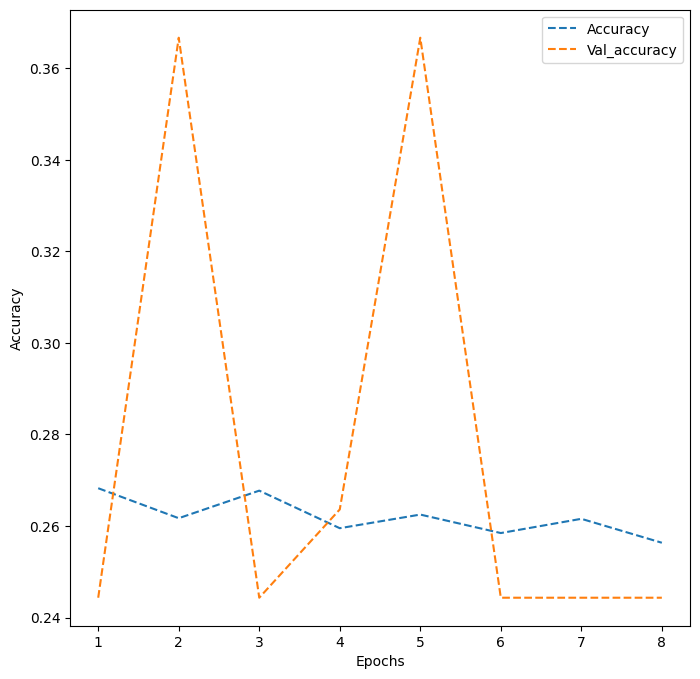

In [ ]:
# Plot training and validation accuracies
res_hist = history_res.history
list_epochs = [i for i in range(1, 9)]

plt.figure(figsize=(8, 8))

plt.plot(list_epochs, res_hist['accuracy'], ls='--', label='Accuracy')
plt.plot(list_epochs, res_hist['val_accuracy'], ls='--', label='Val_accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

**Observations and Insights:** This model performed poorly on the data, with the training accuracy actually steadily decreasing. This suggests that ResNet isn't a very good architecture for this problem. This is most likely because the data isn't complex enough, being only 48x48 images and black and white.

**Note: You can even go back and build your own architecture on top of the ResNet Transfer layer and see if you can improve the performance.**

## **EfficientNet Model**

In [ ]:
# Clear backend
backend.clear_session()

# Fixing the seed after clearing backend
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### **Model Building**

- Import EfficientNet upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
EfficientNet = ap.EfficientNetV2B2(include_top=False, weights="imagenet", input_shape= (48, 48, 3))

EfficientNet.summary()

35839040/35839040 [==============================] - 0s 0us/step
Model: "efficientnetv2-b2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 48, 48, 3)]          0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 48, 48, 3)            0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 48, 48, 3)            0         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 stem_conv (Conv2

In [ ]:
transfer_layer_EfficientNet = EfficientNet.get_layer('block6e_expand_activation')
EfficientNet.trainable = False

# Add your Flatten layer.
x = Flatten()(transfer_layer_EfficientNet.output)

# Add your Dense layers and/or BatchNormalization and Dropout layers
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# Add your final Dense layer with 4 neurons and softmax activation function.
pred = Dense(4, activation='softmax')(x)

Efficientnetmodel = Model(EfficientNet.input, pred)

### **Compiling and Training the Model**

In [ ]:
checkpoint = ModelCheckpoint("./efficientmodel.h5", monitor = 'val_accuracy', verbose = 1, save_best_only = True, mode = 'max')

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

In [ ]:
# Compile the model
Efficientnetmodel.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

Efficientnetmodel.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 48, 48, 3)]          0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 48, 48, 3)            0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 48, 48, 3)            0         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 stem_conv (Conv2D)          (None, 24, 24, 32)           864       ['normalization[0][0]']   

In [ ]:
history_eff = Efficientnetmodel.fit(train_set,
                              epochs=20,
                              batch_size=batch_size,
                              validation_data=validation_set,
                              callbacks=callbacks_list)

Epoch 1/20
473/473 [==============================] - ETA: 0s - loss: 1.5646 - accuracy: 0.2532
Epoch 1: val_accuracy improved from -inf to 0.36669, saving model to ./efficientmodel.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


473/473 [==============================] - 128s 241ms/step - loss: 1.5646 - accuracy: 0.2532 - val_loss: 1.4079 - val_accuracy: 0.3667 - lr: 0.0010
Epoch 2/20
473/473 [==============================] - ETA: 0s - loss: 1.4549 - accuracy: 0.2523
Epoch 2: val_accuracy did not improve from 0.36669
473/473 [==============================] - 130s 274ms/step - loss: 1.4549 - accuracy: 0.2523 - val_loss: 1.3464 - val_accuracy: 0.3667 - lr: 0.0010
Epoch 3/20
473/473 [==============================] - ETA: 0s - loss: 1.4183 - accuracy: 0.2632
Epoch 3: val_accuracy did not improve from 0.36669
473/473 [==============================] - 126s 266ms/step - loss: 1.4183 - accuracy: 0.2632 - val_loss: 1.4094 - val_accuracy: 0.2289 - lr: 0.0010
Epoch 4/20
473/473 [==============================] - ETA: 0s - loss: 1.4044 - accuracy: 0.2608
Epoch 4: val_accuracy did not improve from 0.36669
473/473 [==============================] - 129s 273ms/step - loss: 1.4044 - accuracy: 0.2608 - val_loss: 1.3867 - v

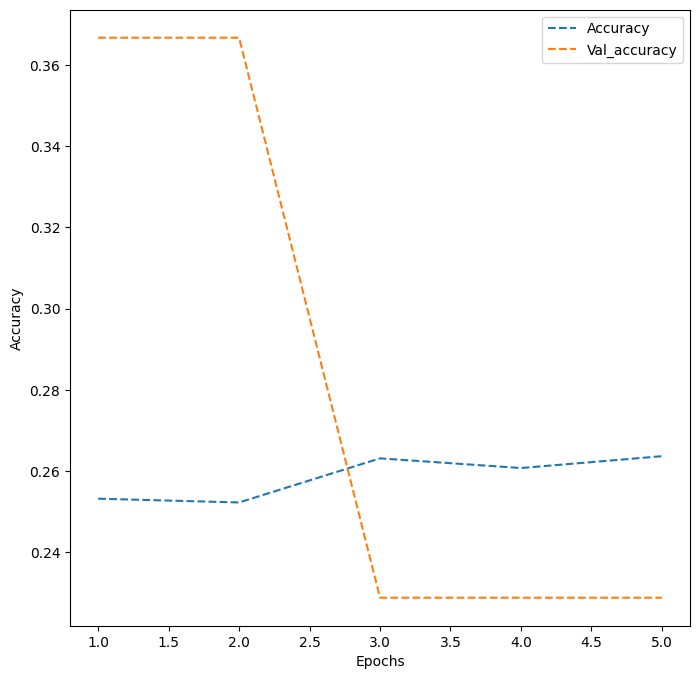

In [ ]:
# Plot training and validation accuracies
eff_hist = history_eff.history
list_epochs = [i for i in range(1, 6)]

plt.figure(figsize=(8, 8))

plt.plot(list_epochs, eff_hist['accuracy'], ls='--', label='Accuracy')
plt.plot(list_epochs, eff_hist['val_accuracy'], ls='--', label='Val_accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

### **Evaluating the EfficientnetNet Model**

**Observations and Insights:** Similarly with ResNet, Effiectnet performs poorly on this dataset, most likely to do with the data not being complex enough.

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance.**

**Think About It:**

* What is your overall performance of these Transfer Learning Architectures? Can we draw a comparison of these models' performances. Are we satisfied with the accuracies that we have received?
* Do you think our issue lies with 'rgb' color_mode?

**Observations:** Based on the performance from using transfer learning, VGG was the only one that showed promise, although the accuracy still wasn't satisfactory.

Now that we have tried multiple pre-trained models, let's build a complex CNN architecture and see if we can get better performance.

## **Building a Complex Neural Network Architecture**

In this section, we will build a more complex Convolutional Neural Network Model that has close to as many parameters as we had in our Transfer Learning Models. However, we will have only 1 input channel for our input images.

## **Creating our Data Loaders**

In this section, we are creating data loaders which we will use as inputs to the more Complicated Convolutional Neural Network. We will go ahead with color_mode = 'grayscale'.

In [ ]:
# Creating data generators for train, validation and test set with color_mode = 'grayscale'
datagen_train_gray = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

train_set_gray = datagen_train_gray.flow_from_directory('Facial_emotion_images/train',
                                              target_size = (image_size, image_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)

datagen_validation_gray = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

validation_set_gray = datagen_validation_gray.flow_from_directory('Facial_emotion_images/validation',
                                              target_size = (image_size, image_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)

datagen_test_gray = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

test_set_gray = datagen_test_gray.flow_from_directory('Facial_emotion_images/test',
                                              target_size = (image_size, image_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


### **Model Building**

- Try building a layer with 5 Convolutional Blocks and see if performance increases.

In [ ]:
# Clear backend
backend.clear_session()

# Fixing the seed after clearing backend
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Set up input_shape with 1 channel for grayscale
input_shape=(image_size, image_size, 1)
num_classes=4

checkpoint = ModelCheckpoint("./model4.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 3,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 3,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

# Define the model
def cnn_model_3(input_shape=input_shape, num_classes=num_classes):
    # Initialize the model
    model = Sequential()

    # First Conv block
    model.add(Conv2D(128, (2, 2), padding='same', activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))

    # Second Convolutional Block
    model.add(Conv2D(128, (2, 2), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))

    # Third Convolutional Block
    model.add(Conv2D(256, (2, 2), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))

    # Fourth Convolutional Block
    model.add(Conv2D(512, (2, 2), padding='same', activation='relu'))
    model.add(Dropout(0.2))

    # Fifth Convolutional Block
    model.add(Conv2D(512, (2, 2), padding='same', activation='relu'))
    model.add(Dropout(0.2))

    # Flatten layer
    model.add(Flatten())

    # Dense layers
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(4, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

### **Compiling and Training the Model**

In [ ]:
model4 = cnn_model_3()

model4.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 128)       640       
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 128)       0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 24, 24, 128)       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 128)       65664     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 12, 12, 128)       0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 12, 12, 128)       0

In [ ]:
history3 = model4.fit(train_set_gray,
                     epochs=20,
                     validation_data=validation_set_gray,
                     callbacks=callbacks_list)

Epoch 1/20
473/473 [==============================] - ETA: 0s - loss: 1.3826 - accuracy: 0.2632
Epoch 1: val_accuracy improved from -inf to 0.35624, saving model to ./model4.h5
473/473 [==============================] - 415s 873ms/step - loss: 1.3826 - accuracy: 0.2632 - val_loss: 1.3618 - val_accuracy: 0.3562 - lr: 0.0010
Epoch 2/20


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


473/473 [==============================] - ETA: 0s - loss: 1.3219 - accuracy: 0.3410
Epoch 2: val_accuracy improved from 0.35624 to 0.44002, saving model to ./model4.h5
473/473 [==============================] - 425s 898ms/step - loss: 1.3219 - accuracy: 0.3410 - val_loss: 1.2328 - val_accuracy: 0.4400 - lr: 0.0010
Epoch 3/20
473/473 [==============================] - ETA: 0s - loss: 1.1882 - accuracy: 0.4603
Epoch 3: val_accuracy improved from 0.44002 to 0.50894, saving model to ./model4.h5
473/473 [==============================] - 410s 867ms/step - loss: 1.1882 - accuracy: 0.4603 - val_loss: 1.1348 - val_accuracy: 0.5089 - lr: 0.0010
Epoch 4/20
473/473 [==============================] - ETA: 0s - loss: 1.1280 - accuracy: 0.4947
Epoch 4: val_accuracy improved from 0.50894 to 0.53586, saving model to ./model4.h5
473/473 [==============================] - 427s 902ms/step - loss: 1.1280 - accuracy: 0.4947 - val_loss: 1.0451 - val_accuracy: 0.5359 - lr: 0.0010
Epoch 5/20
473/473 [=======

### **Evaluating the Model on Test Set**

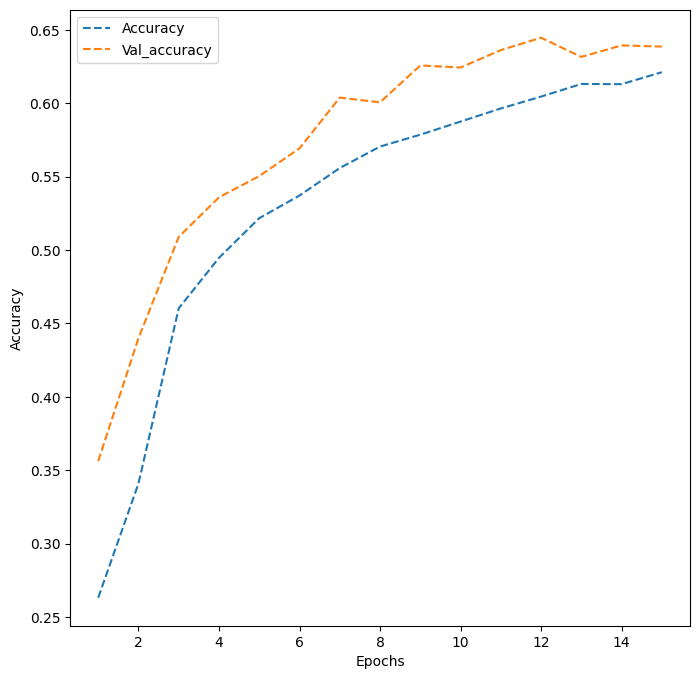

In [ ]:
# Plot training and validation accuracies
dict_hist3 = history3.history
list_epochs = [i for i in range(1, 16)]

plt.figure(figsize=(8, 8))

plt.plot(list_epochs, dict_hist3['accuracy'], ls='--', label='Accuracy')
plt.plot(list_epochs, dict_hist3['val_accuracy'], ls='--', label='Val_accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

**Observations and Insights:** This model didn't perform better than the earlier models. This code be either because the model was too complex, so reducing the amount of nodes in each layer could increase performance, or we may require more data to be able to train a model from scratch with a satisfactory performance.

### **Plotting the Confusion Matrix for the chosen final model**

1/1 [==============================] - 1s 1s/step


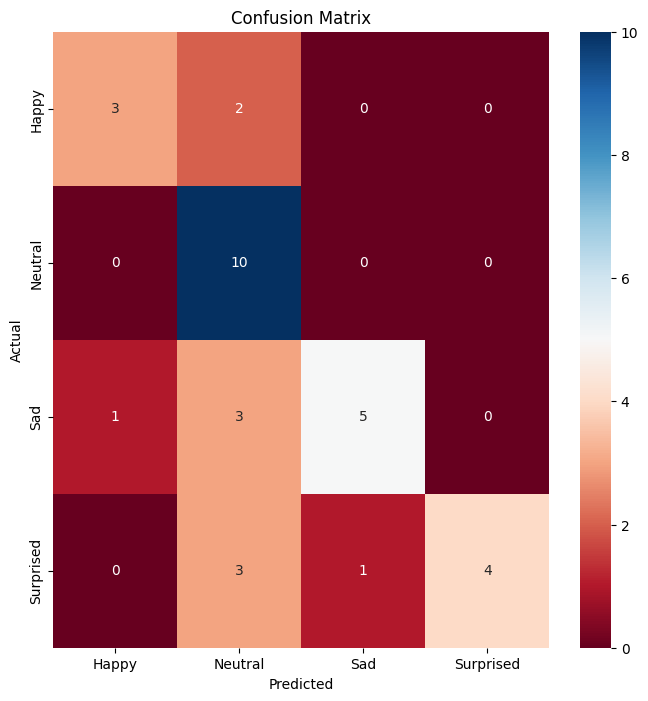

In [ ]:
pred = vggmodel.predict(test_images)

# Turn predicted values into single values
pred = np.argmax(pred, axis=1)
y_true = np.argmax(test_labels, axis=1)

cm = confusion_matrix(y_true, pred)

# Get class labels
classes = ['Happy', 'Neutral', 'Sad', 'Surprised']

# Plot the heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='.0f', xticklabels=classes, yticklabels=classes, cmap='RdBu')

# Set labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Show the plot
plt.show()

**Observations and Insights:** While VGG appeared to have performed slightly worse on the test data, it is most likely that on a much larger set of test data it will generalize better than the other models.

## **Conclusion:**
In conclusion, VGG would be my choice of network to proceed with. The fact that the majority of incorrect guesses were neutral, looking through the pictures that were incorrectly labelled as neutral would be a good next step to see what the actual reason for this was.

After this we can test if increasing the threshold for selecting neutral classes could increase the performance. If all of the correct choices for neutral were above, say, 70%, but when they were incorrectly labelled the model predicted 60% neutral, 30% the correct class and 10% the other 2, this could result in a good model.

If this doesn't prove to be helpful, my next step would be to try and increase the complexity slowly to try and be able to capture the underlying patterns better, along with tuning other hyperparameters such as batch_size, dropout amount and number of nodes in each layer.



### **Insights**

### **Refined insights**:
- What are the most meaningful insights from the data relevant to the problem?

### **Comparison of various techniques and their relative performance**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

### **Proposal for the final solution design**:
- What model do you propose to be adopted? Why is this the best solution to adopt?